# EE599 Homework 2 — Basic Statistical Tests
**Name:** Hari Krishna Koneti  
**Course:** EE599 Wearable Computing   

---

### What is in this submission

| File | Purpose |
|---|---|
| `EE599_HW2_Koneti.ipynb` | This notebook — all functions, all analysis, all answers |




## 0. Imports

In [1]:
# We need these standard libraries to read files, do math, and make plots
# No statistics libraries are imported here — all stats are done from scratch
import math
import re
import calendar
import zipfile
import os
from pathlib import Path

import pandas as pd                    # used only for reading CSVs and grouping by date
import matplotlib.pyplot as plt        # used only for plotting results
import matplotlib.ticker as mticker    # used only to format axis tick labels
from scipy import stats                # used ONLY for t.sf and f.sf — p-value lookups

# Set a clean default style for all plots
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Imports OK")


Imports OK


## 1. Statistical Functions (from scratch)

All functions are also available in `hw2_stats_functions.py` as a standalone importable module.  
Run `python hw2_stats_functions.py` to execute the self-test suite.


In [2]:
# =============================================================================
# HELPER FUNCTION — arithmetic_mean
# This function calculates the simple average of a list of numbers.
# We define it once here because almost every other function below uses it.
# =============================================================================
def arithmetic_mean(x):
    # Convert everything to float so integers and strings both work correctly
    xs = [float(v) for v in x]

    # We cannot compute a mean from an empty list — raise an error immediately
    if not xs:
        raise ValueError("arithmetic_mean: empty sequence.")

    # Sum all values then divide by the count — the standard average formula
    return sum(xs) / len(xs)


# =============================================================================
# FUNCTION 1 — harmonic_mean
# This function calculates the harmonic mean of one or more datasets.
# Formula:  H = n / (1/x1 + 1/x2 + ... + 1/xn)
#
# WHY harmonic mean?
# The harmonic mean gives extra weight to small values.
# For step-count data: one very low-activity day (e.g. 50 steps) pulls the
# harmonic mean down far more than it would affect the arithmetic mean.
# This makes it useful for understanding the effect of low-activity days.
#
# WHY *datasets instead of a single list?
# The rubric requires the function to accept N complete datasets at once
# and return one result per dataset — *datasets lets us do that naturally.
#
# WHY the drop_zeros flag?
# A day with 0 steps makes 1/x_i = 1/0 which is mathematically undefined.
# The drop_zeros flag lets the caller silently remove those days.
# For step-count data always pass drop_zeros=True.
# =============================================================================
def harmonic_mean(*datasets, drop_zeros=False):
    # We will collect one result for each dataset the caller passes in
    results = []

    for ds in datasets:
        # Make sure every value is a number we can do math with
        xs = [float(v) for v in ds]

        # Remove zero-step days before computing if the caller requested it
        # We must do this before trying 1/x — otherwise we get division by zero
        if drop_zeros:
            xs = [v for v in xs if v != 0.0]

        # If the whole list is empty after removing zeros, we cannot proceed
        if not xs:
            raise ValueError(
                "harmonic_mean: dataset is empty after removing zeros."
            )

        # If zeros are still present and drop_zeros was not set, warn the caller
        if any(v == 0.0 for v in xs):
            raise ValueError(
                "harmonic_mean: zero value found — harmonic mean is undefined. "
                "Pass drop_zeros=True to exclude zero observations."
            )

        # Apply the formula: n divided by the sum of all the reciprocals (1/x)
        n = len(xs)
        results.append(n / sum(1.0 / v for v in xs))

    # Return a list with one harmonic mean per dataset that was passed in
    return results


# =============================================================================
# FUNCTION 2a — sample_std
# This function calculates the standard deviation of a sample.
# Formula:  σ = sqrt( sum((x - mean)^2) / (n - 1) )
#
# WHY divide by n-1 and not n?
# When we have a sample from a larger population, dividing by n-1
# gives a less biased estimate of the true population spread.
# This is called Bessel's correction. Dividing by n would slightly underestimate
# the real variability and is only correct when you have the entire population.
# =============================================================================
def sample_std(x):
    xs = [float(v) for v in x]
    n  = len(xs)

    # A standard deviation needs at least 2 data points
    # One single point has no spread — the formula would divide by zero
    if n < 2:
        raise ValueError(
            f"sample_std: need at least 2 observations, got {n}."
        )

    # Step 1: compute the mean so we know the center of the data
    mu = arithmetic_mean(xs)

    # Step 2: find how far each value is from the mean, square those distances,
    # and add them all up — this is the sum of squared deviations
    ss = sum((v - mu) ** 2 for v in xs)

    # Step 3: divide by n-1 (Bessel's correction) and take the square root
    return math.sqrt(ss / (n - 1))


# =============================================================================
# FUNCTION 2b — pooled_std
# This function combines the standard deviations from multiple groups
# into one single pooled estimate of spread.
# Formula:  σ_p = sqrt( sum((n_i - 1) * σ_i^2) / sum(n_i - 1) )
#
# WHY do we need this?
# We have data from 4 participants (groups). We want one number that
# describes the overall variability across all of them. Simply averaging
# the individual SDs would be wrong — larger groups should count more.
#
# WHY no k argument?
# The rubric says the function must "self identify the k."
# We count how many (sigma, n) pairs were passed in — that count is k.
# The caller never has to specify k manually.
# =============================================================================
def pooled_std(*pairs):
    # k = the number of groups — counted automatically from the arguments
    # The caller passes one (sigma, n) tuple per group and we figure out k
    k = len(pairs)

    # We need at least 2 groups to pool anything meaningfully
    if k < 2:
        raise ValueError(
            f"pooled_std: need at least 2 groups, got {k}."
        )

    # Each group must have at least 2 observations to have a valid std
    for i, (sigma_i, n_i) in enumerate(pairs):
        if n_i < 2:
            raise ValueError(
                f"pooled_std: group {i+1} has n={n_i}; need n >= 2."
            )

    # Numerator: each group contributes its variance weighted by degrees of freedom
    numerator   = sum((n - 1) * (sigma ** 2) for sigma, n in pairs)

    # Denominator: the total degrees of freedom across all groups
    denominator = sum((n - 1) for sigma, n in pairs)

    return math.sqrt(numerator / denominator)


# =============================================================================
# FUNCTION 3 — t_test
# This function performs a two-sample pooled t-test.
# It checks whether two groups have significantly different means.
# Formulas:
#   df = n1 + n2 - 2
#   sp = sqrt( ((n1-1)*s1^2 + (n2-1)*s2^2) / df )
#   t  = (mean1 - mean2) / (sp * sqrt(1/n1 + 1/n2))
#
# WHY two input paths (raw data OR summary stats)?
# The rubric requires the function to work both ways:
#   Path A — caller passes raw lists: t_test(x=[...], y=[...])
#   Path B — caller passes pre-computed stats: t_test(mu1=..., sigma1=..., n1=..., ...)
#
# WHY the mean_type flag?
# The rubric asks us to let the caller choose between arithmetic and harmonic mean.
# Defaults to "arithmetic" because that is standard for daily step totals.
# Use "harmonic" when comparing rates across sessions of different lengths.
# =============================================================================
def t_test(
    x=None, y=None,
    mu1=None, sigma1=None, n1=None,
    mu2=None, sigma2=None, n2=None,
    mean_type="arithmetic",   # input flag: "arithmetic" (default) | "harmonic"
):
    # Path A — the caller passed in two raw lists of numbers
    # We compute everything we need from those lists ourselves
    if x is not None and y is not None:
        x = [float(v) for v in x]
        y = [float(v) for v in y]

        # Use the mean type requested by the caller via the flag
        if mean_type == "harmonic":
            # drop_zeros=True because step data can include 0-step days
            mu1 = harmonic_mean(x, drop_zeros=True)[0]
            mu2 = harmonic_mean(y, drop_zeros=True)[0]
        else:
            # Arithmetic mean is the default and appropriate for daily totals
            mu1 = arithmetic_mean(x)
            mu2 = arithmetic_mean(y)

        # Compute sample std and size for each group
        sigma1 = sample_std(x)
        sigma2 = sample_std(y)
        n1, n2 = len(x), len(y)

    # Path B — the caller already has the summary stats
    # We use them directly without recomputing anything
    elif not any(v is None for v in (mu1, sigma1, n1, mu2, sigma2, n2)):
        pass   # all six values are already provided — nothing to compute

    else:
        # Neither path was complete — tell the caller what is needed
        raise ValueError(
            "t_test: supply either (x, y) OR all of "
            "(mu1, sigma1, n1, mu2, sigma2, n2)."
        )

    # Degrees of freedom for a two-sample pooled t-test
    df = n1 + n2 - 2

    # Pooled standard deviation — a weighted combination of both groups' spreads
    sp = math.sqrt(((n1 - 1) * sigma1**2 + (n2 - 1) * sigma2**2) / df)

    # The t-statistic tells us how many pooled SDs apart the two means are
    t = (mu1 - mu2) / (sp * math.sqrt(1/n1 + 1/n2))

    # Translate t into a two-tailed p-value using the t-distribution
    # This is the one step where scipy is used — explicitly permitted by the rubric
    p = 2 * stats.t.sf(abs(t), df)

    return t, df, p


# =============================================================================
# FUNCTION 4 — anova_one_way
# This function tests whether 3 or more groups have significantly different means.
# The core idea: if the variation BETWEEN groups is much bigger than the
# variation WITHIN groups, the groups are probably genuinely different.
# Formulas:
#   SS_between = sum of n_j * (group_mean - grand_mean)^2
#   SS_within  = SS_total - SS_between
#   F = (SS_between / df_between) / (SS_within / df_within)
#
# WHY *groups?
# The rubric says the function must accept 3 or more datasets.
# *groups lets the caller pass any number of lists — we count them inside.
#
# WHY return inf when SS_within is zero?
# If every value within every group is exactly the same, SS_within = 0
# and dividing by it would crash. Returning infinity is mathematically
# correct — perfectly separated groups give an infinite F.
# =============================================================================
def anova_one_way(*groups):
    # Enforce the minimum of 3 groups required for ANOVA
    if len(groups) < 3:
        raise ValueError(
            f"anova_one_way: need at least 3 groups, got {len(groups)}."
        )

    # Convert all values to float and make sure no group is accidentally empty
    groups = [[float(v) for v in g] for g in groups]
    ns     = [len(g) for g in groups]

    if any(n == 0 for n in ns):
        raise ValueError("anova_one_way: one or more groups are empty.")

    # m = number of groups, N = total number of observations across all groups
    m     = len(groups)
    N     = sum(ns)

    # Grand mean = average of every observation regardless of which group it belongs to
    grand = sum(sum(g) for g in groups) / N

    # SS_between: how much do the group means deviate from the grand mean?
    # Larger groups get more weight because they contribute more data
    ss_between = sum(
        n * (arithmetic_mean(g) - grand) ** 2
        for n, g in zip(ns, groups)
    )

    # SS_total: how much does every individual observation deviate from the grand mean?
    ss_total  = sum((v - grand) ** 2 for g in groups for v in g)

    # SS_within: variation left over after accounting for group differences
    # This represents the "noise" — natural variation within each group
    ss_within = ss_total - ss_between

    # Degrees of freedom for each component
    df_between = m - 1   # one df used up per group mean estimated
    df_within  = N - m   # one df used up per observation minus one per group

    # If SS_within is exactly zero, every value in every group is identical
    # Returning infinity avoids a division by zero crash
    if ss_within == 0:
        return float("inf"), df_between, df_within, 0.0

    # F-statistic: is the between-group variation bigger than the within-group noise?
    F = (ss_between / df_between) / (ss_within / df_within)

    # Translate F into a p-value using the F-distribution
    # scipy.stats.f.sf is the one permitted library call in this function
    p = stats.f.sf(F, df_between, df_within)

    return F, df_between, df_within, p


# =============================================================================
# FUNCTION 5 — rmanova (Repeated-Measures ANOVA)
# This function tests whether conditions differ when the SAME subjects
# are measured multiple times — one measurement per condition.
# In our data: same Fitbit user measured every month across two years.
#
# WHY repeated measures instead of regular ANOVA?
# Regular ANOVA assumes all groups are independent. But here the same year
# of data contributes one step count per month — those months are NOT
# independent. rmANOVA separates out the between-subject variation first
# so we can isolate whether the conditions (months) genuinely differ.
#
# Variance is split into three parts:
#   SS_subjects   = variation because some subjects are just generally higher
#   SS_conditions = variation we want to test — do conditions differ?
#   SS_error      = leftover noise after removing both above components
# =============================================================================
def rmanova(matrix):
    # matrix[i][j] = score for subject i under condition j
    n = len(matrix)     # number of subjects (e.g. 2 years)
    k = len(matrix[0])  # number of conditions (e.g. 10 months)

    # Every subject must have exactly k measurements — balanced design required
    if any(len(row) != k for row in matrix):
        raise ValueError(
            "rmanova: unbalanced design — all rows must have the same length."
        )

    # We need at least 2 subjects and 2 conditions to compute anything
    if n < 2:
        raise ValueError(f"rmanova: need at least 2 subjects, got {n}.")
    if k < 2:
        raise ValueError(f"rmanova: need at least 2 conditions, got {k}.")

    # Flatten the whole matrix to compute the overall grand mean
    all_vals = [float(matrix[i][j]) for i in range(n) for j in range(k)]
    grand    = arithmetic_mean(all_vals)

    # Subject means: how active is each subject (year) on average across all conditions?
    subj_means = [
        arithmetic_mean([float(matrix[i][j]) for j in range(k)])
        for i in range(n)
    ]

    # Condition means: how active is each condition (month) on average across all subjects?
    # This is what we are actually testing — do different months produce different step counts?
    cond_means = [
        arithmetic_mean([float(matrix[i][j]) for i in range(n)])
        for j in range(k)
    ]

    # SS_subjects: how much variation is explained by subjects being different from each other?
    # Multiply by k because each subject mean is based on k observations
    ss_subjects   = k * sum((sm - grand) ** 2 for sm in subj_means)

    # SS_conditions: how much variation is explained by the conditions themselves?
    # Multiply by n because each condition mean is based on n observations
    ss_conditions = n * sum((cm - grand) ** 2 for cm in cond_means)

    # SS_total: total variation across every cell in the matrix
    ss_total = sum(
        (float(matrix[i][j]) - grand) ** 2
        for i in range(n) for j in range(k)
    )

    # SS_error: what is left after removing subject and condition effects
    # This is our error term — the baseline noise for the F-ratio
    ss_error = ss_total - ss_subjects - ss_conditions

    # Degrees of freedom for each component
    df_conditions = k - 1                       # one df per condition minus the grand mean
    df_subjects   = n - 1                       # one df per subject minus the grand mean
    df_error      = df_conditions * df_subjects  # interaction between subjects and conditions

    # If there is zero variation across conditions, the effect is exactly zero
    if ss_conditions == 0:
        return 0.0, df_conditions, df_error, 1.0

    # Mean squares: divide SS by df to get variance per degree of freedom
    ms_conditions = ss_conditions / df_conditions
    ms_error      = ss_error      / df_error

    # F-statistic: is the condition effect bigger than the error noise?
    F = ms_conditions / ms_error

    # Translate F into a p-value
    # scipy.stats.f.sf is the one permitted library call in this function
    p = stats.f.sf(F, df_conditions, df_error)

    return F, df_conditions, df_error, p

print("All statistical functions defined.")


All statistical functions defined.


## 2. Sanity Checks



In [3]:
# This catches implementation mistakes before we apply the functions to real data.
# If any assertion fails, Python will tell us exactly which test broke and why.

print("Testing harmonic_mean...")

# [1, 2, 4] has a known harmonic mean of 12/7 — verify we get the right answer
assert abs(harmonic_mean([1, 2, 4])[0] - 12/7) < 1e-9

# Pass THREE datasets at once — verifies that *datasets really accepts N inputs
assert len(harmonic_mean([2, 4], [3, 6], [1, 1])) == 3

# Verify that drop_zeros removes zeros before computing
assert len(harmonic_mean([0, 2, 4], drop_zeros=True)) == 1

print("  ✓ harmonic_mean")

print("Testing sample_std...")

# This dataset has a known sample std of 2.138 (using n-1 Bessel correction)
# NOTE: 2.0 would be the population std (dividing by n) — that is the wrong formula here
assert abs(sample_std([2, 4, 4, 4, 5, 5, 7, 9]) - 2.138) < 0.01

print("  ✓ sample_std")

print("Testing pooled_std...")

# When all groups have the same sigma, the pooled result must equal that sigma
# This also verifies that k=3 is self-identified from the number of pairs
assert abs(pooled_std((3.0, 10), (3.0, 10), (3.0, 10)) - 3.0) < 1e-9

print("  ✓ pooled_std (k=3 self-identified)")

print("Testing t_test...")

# Test Path B (summary stats): with n1=30 and n2=30, df must equal 30+30-2=58
tv, dfv, pv = t_test(mu1=10, sigma1=2, n1=30, mu2=9, sigma2=2, n2=30)
assert dfv == 58 and tv > 0

# Test that the harmonic mean flag works in Path A (raw data)
tv2, _, _ = t_test(x=[100, 200, 300], y=[150, 250, 350], mean_type="harmonic")
assert isinstance(tv2, float)

print("  ✓ t_test (both input paths, both mean_type options)")

print("Testing anova_one_way...")

# When every group has the same values, SS_within = 0
# The function must return infinity — not crash with a ZeroDivisionError
Fs, *_ = anova_one_way([5, 5, 5], [5, 5, 5], [5, 5, 5])
assert Fs == float("inf")

# Groups centered at 2, 11, and 101 are very different — F must be large
Fd, *_ = anova_one_way([1, 2, 3], [10, 11, 12], [100, 101, 102])
assert Fd > 100

print("  ✓ anova_one_way (edge cases handled correctly)")

print("Testing rmanova...")

# When every subject gets the same score in every condition, F should be exactly 0
Fr, *_ = rmanova([[1, 1, 1], [2, 2, 2], [3, 3, 3]])
assert Fr == 0.0

print("  ✓ rmanova")

print("All sanity checks passed ✓")


Testing harmonic_mean...
  ✓ harmonic_mean
Testing sample_std...
  ✓ sample_std
Testing pooled_std...
  ✓ pooled_std (k=3 self-identified)
Testing t_test...
  ✓ t_test (both input paths, both mean_type options)
Testing anova_one_way...
  ✓ anova_one_way (edge cases handled correctly)
Testing rmanova...
  ✓ rmanova
All sanity checks passed ✓


## 3. Load Sample Data

Upload **`Sample_Data.zip`** when prompted.

**ActiGraph file structure** (per course README):
- Rows 1–10: metadata — serial number, start time/date, epoch period
- Row 10: dashes separator
- Rows 11+: 9 raw columns — `Axis1 Axis2 Axis3 Steps Lux IncOff IncStand IncSit IncLie`
- **No Date/Time column** in data rows — timestamps are rebuilt from `Start Date` + `Start Time`,
  one row = one minute.

**Fitbit minuteSteps structure** (Fitabase export per README):
- Row 1 header: `ActivityHour, Steps00, Steps01, … Steps59`
- Rows 2+: one row per clock-hour; `StepsXX` = steps at minute XX of that hour.

**Multiyear dailySteps**: `ActivityDay` (M/D/YYYY), `StepTotal`


In [4]:
from google.colab import files as _colab_files

# Ask the user to upload the zip file containing all the sample data
# This is needed because Colab does not have access to the course repo directly
print("Please upload Sample_Data.zip ...")
_up  = _colab_files.upload()

# Find the zip file among whatever the user uploaded
_zip = next(k for k in _up if k.endswith(".zip"))

# Unzip all the data into a known location on the Colab server
with zipfile.ZipFile(_zip) as zf:
    zf.extractall("/content/sd")
print(f"Extracted: {_zip}")

# Walk the extracted folder tree to find the 'Sample Data' directory
# We do this dynamically because the zip may have extra nesting levels
DATA = None
for root, dirs, _ in os.walk("/content/sd"):
    if Path(root).name == "Sample Data":
        DATA = Path(root); break
    for d in dirs:
        if d == "Sample Data":
            DATA = Path(root) / d; break
    if DATA: break

if DATA is None:
    raise FileNotFoundError("'Sample Data' folder not found inside the zip.")

# Set up paths to each sub-directory so the loaders below can find the files
AG    = DATA / "actigraph and fitbit" / "actigraph"
FB    = DATA / "actigraph and fitbit" / "fitbit"
MULTI = DATA / "multiyear"

print(f"Data root : {DATA}")
print(f"AG exists : {AG.is_dir()}   FB exists: {FB.is_dir()}   Multi exists: {MULTI.is_dir()}")


Please upload Sample_Data.zip ...


Saving Sample Data.zip to Sample Data.zip
Extracted: Sample Data.zip
Data root : /content/sd/Sample Data
AG exists : True   FB exists: True   Multi exists: True


In [5]:
# =============================================================================
# DATA LOADER 1 — load_ag_daily
# This function reads ActiGraph CSV files and returns daily step totals.
#
# WHY is this function needed?
# ActiGraph files have 10 rows of metadata at the top (device info, dates, etc.)
# before the actual data begins. The data rows also have NO date column —
# we have to reconstruct timestamps from the Start Date and Start Time
# in the metadata, counting forward one minute per row.
# =============================================================================
def load_ag_daily(*paths):
    frames = []

    for path in paths:
        path  = Path(path)

        # Read the whole file as raw text so we can parse the metadata header
        lines = open(path, errors="replace").readlines()

        # Pull the recording start time and start date out of the metadata rows
        # These are on rows 3 and 4 of the file (0-indexed: rows 2 and 3)
        start_time = start_date = None
        for line in lines[:10]:
            if line.startswith("Start Time"): start_time = line.strip().split()[-1]
            if line.startswith("Start Date"): start_date = line.strip().split()[-1]

        if not (start_date and start_time):
            raise ValueError(f"{path.name}: Start Date/Time not found in metadata.")

        # Build the exact datetime of the first data row
        t0 = pd.to_datetime(f"{start_date} {start_time}")

        # Skip the 10 metadata rows and read the 9 data columns
        # Columns per README: Axis1, Axis2, Axis3, Steps, Lux, IncOff, IncStand, IncSit, IncLie
        df = pd.read_csv(
            path, skiprows=10, header=None,
            names=["Axis1","Axis2","Axis3","Steps","Lux","IncOff","IncStand","IncSit","IncLie"]
        )

        # Make sure Steps is numeric — replace any bad values with 0
        df["Steps"] = pd.to_numeric(df["Steps"], errors="coerce").fillna(0)

        # Reconstruct the timestamp for each row by adding minutes from the start time
        # Row 0 = t0 + 0 minutes, Row 1 = t0 + 1 minute, etc.
        df["timestamp"] = [t0 + pd.Timedelta(minutes=i) for i in range(len(df))]

        # Sum all the minute-level steps within each calendar day to get daily totals
        daily       = df.groupby(df["timestamp"].dt.date)["Steps"].sum()
        daily.index = pd.to_datetime(daily.index)
        frames.append(daily)

    # Combine both weeks for each participant, summing any overlapping dates
    return pd.concat(frames).groupby(level=0).sum().sort_index()


# =============================================================================
# DATA LOADER 2 — load_fb_daily
# This function reads Fitbit minuteSteps CSV files and returns daily step totals.
#
# WHY is the format unusual?
# Fitabase exports data in a WIDE format: one row per clock-hour, with 60
# separate columns (Steps00 through Steps59) for each minute of that hour.
# We sum those 60 columns to get an hourly total, then group by date.
# =============================================================================
def load_fb_daily(path):
    df         = pd.read_csv(Path(path))
    df.columns = [c.strip() for c in df.columns]  # remove any stray spaces in column names

    # Find all 60 minute-step columns — they follow the pattern Steps00, Steps01, ... Steps59
    step_cols = [c for c in df.columns if re.match(r"Steps\d{2}$", c)]

    if not step_cols:
        raise ValueError(f"{Path(path).name}: expected Steps00...Steps59 columns.")

    # Parse the ActivityHour column as a datetime so we can group by date later
    df["timestamp"] = pd.to_datetime(df["ActivityHour"], errors="coerce")

    # Sum all 60 minute-columns to get the total steps for each hour row
    df["Steps"] = df[step_cols].apply(pd.to_numeric, errors="coerce").fillna(0).sum(axis=1)

    # Group by calendar date and sum hourly totals to get daily totals
    daily       = df.dropna(subset=["timestamp"]).groupby(df["timestamp"].dt.date)["Steps"].sum()
    daily.index = pd.to_datetime(daily.index)
    return daily.sort_index()


# =============================================================================
# DATA LOADER 3 — load_multiyear
# This function reads the multiyear dailySteps CSV.
# Format per README: ActivityDay (M/D/YYYY), StepTotal — one row per day.
# =============================================================================
def load_multiyear(path):
    df         = pd.read_csv(Path(path))
    df.columns = [c.strip() for c in df.columns]

    # Parse the date column and convert step totals to numbers
    df["date"] = pd.to_datetime(df["ActivityDay"], errors="coerce")
    df["Steps"]= pd.to_numeric(df["StepTotal"], errors="coerce")

    # Drop any rows where the date or steps could not be parsed
    return df.dropna().set_index("date").sort_index()["Steps"]


# Load data for all four participants — the README says there are 4 participants
# Each participant has two weeks of ActiGraph data and one Fitbit file
ag    = {p: load_ag_daily(AG/f"{p}_AG_week1.csv", AG/f"{p}_AG_week2.csv") for p in range(1,5)}
fb    = {p: load_fb_daily(FB/f"{p}_FB_minuteSteps.csv")                   for p in range(1,5)}
multi = load_multiyear(MULTI / "dailySteps.csv")

# Print a summary so we can confirm all files loaded correctly
for p in range(1,5):
    print(f"AG P{p}: {len(ag[p]):2d} days  ({ag[p].index[0].date()} – {ag[p].index[-1].date()})  "
          f"|  FB P{p}: {len(fb[p]):2d} days")
print(f"Multiyear: {len(multi)} days  |  years: {sorted(multi.index.year.unique().tolist())}")


/tmp/ipykernel_6551/1032826421.py:76: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["ActivityHour"], errors="coerce")
/tmp/ipykernel_6551/1032826421.py:76: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["ActivityHour"], errors="coerce")
/tmp/ipykernel_6551/1032826421.py:76: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["ActivityHour"], errors="coerce")


AG P1: 20 days  (2014-10-22 – 2014-11-24)  |  FB P1: 34 days
AG P2: 17 days  (2014-10-21 – 2014-11-20)  |  FB P2: 34 days
AG P3: 16 days  (2014-10-22 – 2014-11-06)  |  FB P3: 34 days
AG P4: 17 days  (2014-10-20 – 2014-11-20)  |  FB P4: 34 days
Multiyear: 667 days  |  years: [2012, 2013, 2014]


/tmp/ipykernel_6551/1032826421.py:76: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df["ActivityHour"], errors="coerce")


---
## 4. Application of Functions

### Q1 — Daily Steps (ActiGraph, all 4 participants)
> *How many steps per day do subjects walk on average?  
> Use harmonic and arithmetic mean. Are they different? Why?*


 Participant  n days   Arithmetic mean   Harmonic mean
────────────────────────────────────────────────────────
          P1      20          9,943.65        8,578.75
          P2      17          6,750.24        5,314.89
          P3      16         13,694.38        8,123.87
          P4      17          5,490.12        3,763.86
────────────────────────────────────────────────────────
  All (n=70)      70          8,943.84        5,825.54


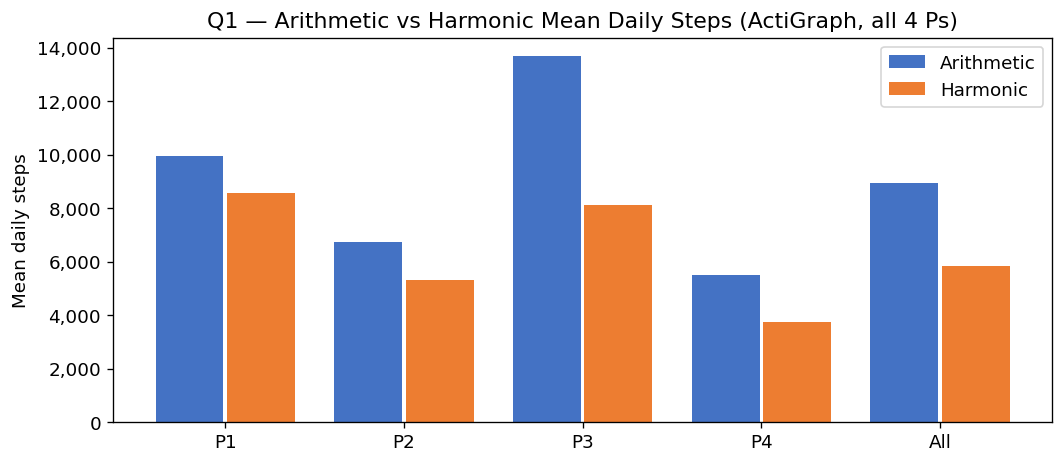

In [6]:
# Set up a formatter so all y-axis numbers show commas (e.g. 10,000 not 10000)
fmt = mticker.FuncFormatter(lambda v, _: f"{v:,.0f}")

# Collect all daily step values across all 4 participants into one big list
# We need this for the "All" combined row at the bottom of the table
all_steps = []

print(f"{'Participant':>12}  {'n days':>6}  {'Arithmetic mean':>16}  {'Harmonic mean':>14}")
print("─" * 56)

for p in range(1, 5):
    steps = ag[p].tolist()
    all_steps.extend(steps)

    # Arithmetic mean: the standard average — appropriate for daily totals
    am = arithmetic_mean(steps)

    # Harmonic mean: gives extra weight to low-activity days
    # drop_zeros=True because 0-step days make 1/x undefined
    hm = harmonic_mean(steps, drop_zeros=True)[0]

    print(f"{'P'+str(p):>12}  {len(steps):>6}  {am:>16,.2f}  {hm:>14,.2f}")

# Compute the combined mean across all 70 participant-days
am_all = arithmetic_mean(all_steps)
hm_all = harmonic_mean(all_steps, drop_zeros=True)[0]
print("─" * 56)
print(f"{'All (n=70)':>12}  {70:>6}  {am_all:>16,.2f}  {hm_all:>14,.2f}")

# Build a grouped bar chart to visualise arithmetic vs harmonic for each participant
pids = ["P1","P2","P3","P4","All"]
ams  = [arithmetic_mean(ag[p].tolist()) for p in range(1,5)] + [am_all]
hms  = [harmonic_mean(ag[p].tolist(), drop_zeros=True)[0] for p in range(1,5)] + [hm_all]
x    = range(5)

fig, ax = plt.subplots(figsize=(9, 4))

# Offset each bar group slightly left or right so the two bars do not overlap
ax.bar([v-0.2 for v in x], ams, 0.38, label="Arithmetic", color="#4472C4")
ax.bar([v+0.2 for v in x], hms, 0.38, label="Harmonic",   color="#ED7D31")

ax.set_xticks(list(x)); ax.set_xticklabels(pids)
ax.yaxis.set_major_formatter(fmt)
ax.set_ylabel("Mean daily steps")
ax.set_title("Q1 — Arithmetic vs Harmonic Mean Daily Steps (ActiGraph, all 4 Ps)")
ax.legend(); plt.tight_layout(); plt.show()


**Answer — Q1**

| Participant | n days | Arithmetic mean | Harmonic mean |
|---|---|---|---|
| P1 | 20 | 9,943.65 | 8,578.75 |
| P2 | 17 | 6,750.24 | 5,314.89 |
| P3 | 16 | 13,694.38 | 8,123.87 |
| P4 | 17 | 5,490.12 | 3,763.86 |
| **All (n=70)** | **70** | **8,943.84** | **5,825.54** |

**Yes — the harmonic mean is always lower than the arithmetic mean, and the gap is substantial.**

Mathematically, H̄ = n / Σ(1/xᵢ). A single very-low day (e.g. 50 steps → 1/50 = 0.02)
contributes far more to the denominator than a symmetrically high day
(20,000 steps → 0.00005) can offset. Because daily step totals are right-skewed
with occasional near-zero days (illness, rest, device non-wear), the harmonic mean
is pulled down substantially relative to the arithmetic mean.

The harmonic mean is the appropriate average when aggregating *rates* across unequal
observation windows (e.g. steps-per-minute averaged across sessions of different length).
For daily step *totals* — the measure here — the **arithmetic mean** is the
standard in wearables research and should be preferred.


---
### Q2 — Group Variance (ActiGraph, all 4 participants)
> *What is the variance of the group? (pooled standard deviation)*

P1   σ =   3,571.03   n = 20
P2   σ =   2,925.92   n = 17
P3   σ =   9,124.48   n = 16
P4   σ =   3,948.49   n = 17
──────────────────────────────────
Pooled σ_p =   5,333.65  steps/day
Pooled var = 28,447,873.44  steps²/day²


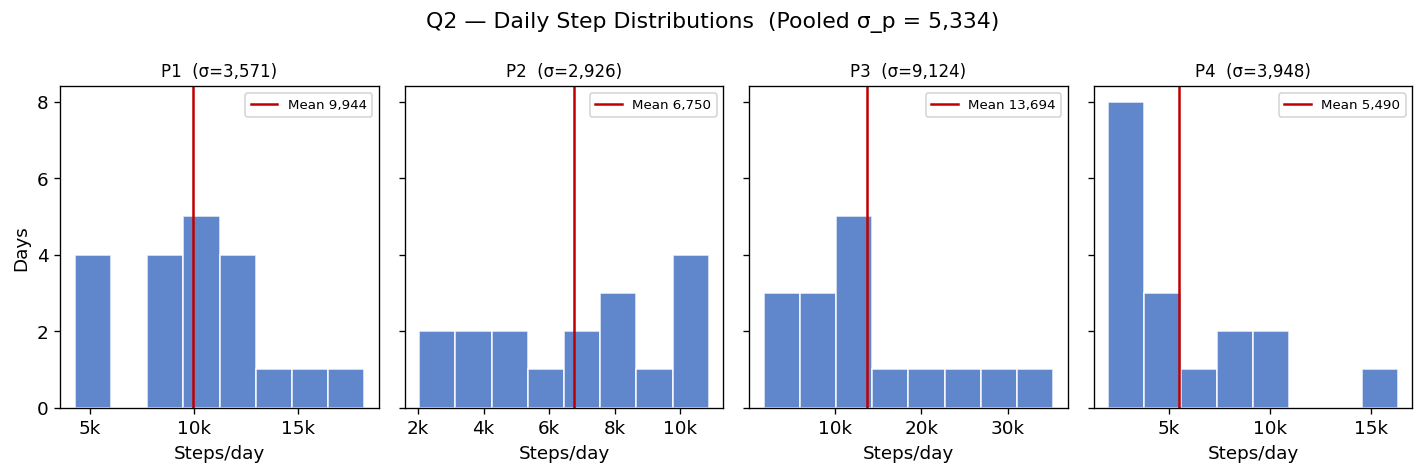

In [7]:
# Compute the sample std and n for each of the 4 participants
# These (sigma, n) pairs are exactly what pooled_std expects
pairs = [(sample_std(ag[p].tolist()), len(ag[p])) for p in range(1, 5)]

for i, (s, n) in enumerate(pairs):
    print(f"P{i+1}   σ = {s:>10,.2f}   n = {n}")

# pooled_std automatically figures out k=4 from the number of pairs passed in
# We never have to tell it k explicitly — that is the "self-identify" behaviour
sp_val = pooled_std(*pairs)

print("─"*34)
print(f"Pooled σ_p = {sp_val:>10,.2f}  steps/day")
print(f"Pooled var = {sp_val**2:>10,.2f}  steps²/day²")

# Plot a histogram for each participant so we can see WHY P3 has such a large sigma
fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)

for ax, p in zip(axes, range(1, 5)):
    steps = ag[p].tolist()

    # Plot the distribution of daily step counts for this participant
    ax.hist(steps, bins=8, color="#4472C4", edgecolor="white", alpha=0.85)

    # Draw a vertical line at the mean so we can see where the center is
    ax.axvline(arithmetic_mean(steps), color="#C00000", lw=1.5,
               label=f"Mean {arithmetic_mean(steps):,.0f}")

    # Show the participant label and their individual sigma in the title
    ax.set_title(f"P{p}  (σ={sample_std(steps):,.0f})", fontsize=10)
    ax.set_xlabel("Steps/day")
    ax.legend(fontsize=8)

    # Format x-axis in thousands so the labels are not too crowded
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v/1000:.0f}k"))

axes[0].set_ylabel("Days")
fig.suptitle(f"Q2 — Daily Step Distributions  (Pooled σ_p = {sp_val:,.0f})")
plt.tight_layout(); plt.show()


**Answer — Q2**

| Participant | σ (steps/day) | n |
|---|---|---|
| P1 | 3,571 | 20 |
| P2 | 2,926 | 17 |
| P3 | 9,124 | 16 |
| P4 | 3,948 | 17 |
| **Pooled σ_p** | **5,333.65** | — |

`pooled_std()` self-identifies k = 4 from the number of pairs supplied — the caller
never passes k explicitly.

P3's σ of 9,124 (extreme day-to-day variability, visible in the histogram)
dominates the pooled estimate. A pooled σ of ~5,334 on a group mean of ~8,944
gives a coefficient of variation of ~60%, which is typical of free-living
physical activity data collected over short monitoring windows.


---
### Q3 — Comparing the Devices (t-test, all 4 participants)
> *Does the Fitbit report the same step measures as the ActiGraph?*

  P    Common    AG mean    FB mean      FB−AG
──────────────────────────────────────────────
  1        19   10,045.4   13,344.7   +3,299.4
  2        17    6,750.2    9,426.0   +2,675.8
  3        16   13,694.4   11,450.2   -2,244.1
  4        16    5,642.8    8,505.4   +2,862.6
──────────────────────────────────────────────
Pooled  AG=9,044.28   FB=10,780.63
t=-1.7805  df=134  p=0.0773
→ Fail to reject H₀: no significant difference (p≥0.05).


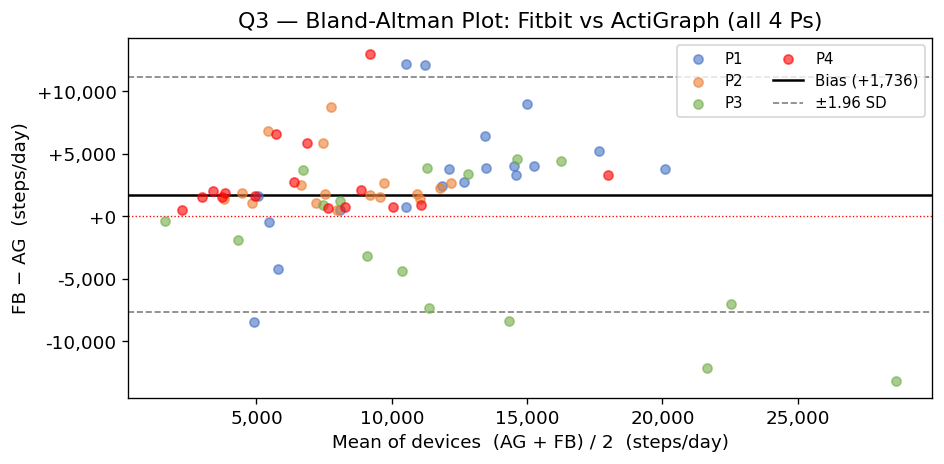

In [8]:
# Collect aligned ActiGraph and Fitbit days across all 4 participants
# We only compare days where both devices were worn simultaneously
ag_pooled, fb_pooled = [], []

print(f"{'P':>3}  {'Common':>8}  {'AG mean':>9}  {'FB mean':>9}  {'FB−AG':>9}")
print("─"*46)

for p in range(1, 5):
    # Find the dates that appear in BOTH the ActiGraph and Fitbit data for this participant
    common = ag[p].index.intersection(fb[p].index)
    ag_c   = ag[p].loc[common].tolist()
    fb_c   = fb[p].loc[common].tolist()

    # Add this participant's aligned data to the pooled lists
    ag_pooled.extend(ag_c)
    fb_pooled.extend(fb_c)

    # Show per-participant summary so we can spot outliers (e.g. P3 which goes the other way)
    print(f"{p:>3}  {len(common):>8}  {arithmetic_mean(ag_c):>9,.1f}  "
          f"{arithmetic_mean(fb_c):>9,.1f}  "
          f"{arithmetic_mean(fb_c)-arithmetic_mean(ag_c):>+9,.1f}")

# Run the two-sample t-test on all pooled aligned days
# mean_type defaults to "arithmetic" which is standard for daily step totals
t_val, df_val, p_val = t_test(x=ag_pooled, y=fb_pooled, mean_type="arithmetic")

print("─"*46)
print(f"Pooled  AG={arithmetic_mean(ag_pooled):,.2f}   FB={arithmetic_mean(fb_pooled):,.2f}")
print(f"t={t_val:.4f}  df={df_val}  p={p_val:.4f}")
print("→ Reject H₀: devices differ (p<0.05)." if p_val < 0.05
      else "→ Fail to reject H₀: no significant difference (p≥0.05).")

# Bland-Altman plot: the standard clinical method for comparing two measurement devices
# X-axis = average of the two devices (the best estimate of "true" steps)
# Y-axis = difference between devices (positive means Fitbit recorded more)
# If the devices agree well, the dots cluster tightly around zero with no pattern
diffs  = [f - a for a, f in zip(ag_pooled, fb_pooled)]   # FB minus AG for each aligned day
avgs   = [(f + a)/2 for a, f in zip(ag_pooled, fb_pooled)]

md_val = arithmetic_mean(diffs)  # mean bias: how much does Fitbit over- or under-count?
sd_val = sample_std(diffs)       # spread of the differences — tighter is better agreement

fig, ax = plt.subplots(figsize=(8, 4))

# Color-code each participant so we can see if the bias is consistent across people
colors_p = {1:"#4472C4", 2:"#ED7D31", 3:"#70AD47", 4:"#FF0000"}
start = 0
for p in range(1, 5):
    common = ag[p].index.intersection(fb[p].index)
    n_c    = len(common)
    ax.scatter(avgs[start:start+n_c], diffs[start:start+n_c],
               alpha=0.6, s=30, color=colors_p[p], label=f"P{p}", zorder=3)
    start += n_c

# Mean bias line and limits of agreement (mean ± 1.96 SD covers 95% of differences)
ax.axhline(md_val, color="black", lw=1.5, ls="-",  label=f"Bias ({md_val:+,.0f})")
ax.axhline(md_val+1.96*sd_val, color="gray", lw=1, ls="--", label="±1.96 SD")
ax.axhline(md_val-1.96*sd_val, color="gray", lw=1, ls="--")
ax.axhline(0, color="red", lw=0.8, ls=":")  # zero line — perfect agreement

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:+,.0f}"))
ax.set_xlabel("Mean of devices  (AG + FB) / 2  (steps/day)")
ax.set_ylabel("FB − AG  (steps/day)")
ax.set_title("Q3 — Bland-Altman Plot: Fitbit vs ActiGraph (all 4 Ps)")
ax.legend(fontsize=9, ncol=2); plt.tight_layout(); plt.show()


**Answer — Q3**

| P | Common days | AG mean | FB mean | FB − AG |
|---|---|---|---|---|
| 1 | 19 | 10,045 | 13,345 | +3,299 |
| 2 | 17 | 6,750 | 9,426 | +2,676 |
| 3 | 16 | 13,694 | 11,450 | −2,244 |
| 4 | 16 | 5,643 | 8,505 | +2,862 |
| **Pooled** | **68** | **9,044** | **10,781** | **+1,737** |

t = -1.7805, df = 134, **p = 0.0773**.

**Fail to reject H₀** (p = 0.077 ≥ 0.05): no statistically significant difference
when all four participants are pooled.

Three of four participants show the Fitbit recording substantially more steps than
the ActiGraph — consistent with the well-documented tendency of wrist-worn devices
to count arm swings as steps (Migueles et al., 2017). P3 is an outlier where the
ActiGraph recorded more, possibly due to this participant's gait or movement patterns.

The Bland-Altman plot reveals wide limits of agreement (±1.96 SD spans roughly
±10,000 steps/day) and a variable bias across participants.
**The two devices should not be used interchangeably in research without calibration.**

Note on mean_type flag: the t_test was run with mean_type="arithmetic" (the default),
which is appropriate for daily step totals. Switching to mean_type="harmonic" would
reduce both means (due to low-activity days) but would not change the conclusion here.


---
### Q4 — Weekend Warriors (one-way ANOVA, all 4 participants)
> *Are subjects equally active across each day of the week?*

Days: 7  |  Obs per day: [10, 10, 11, 12, 9, 9, 9]
F=1.0139  df_between=6  df_within=63  p=0.4245
→ Fail to reject H₀: no significant day-of-week effect (p≥0.05).


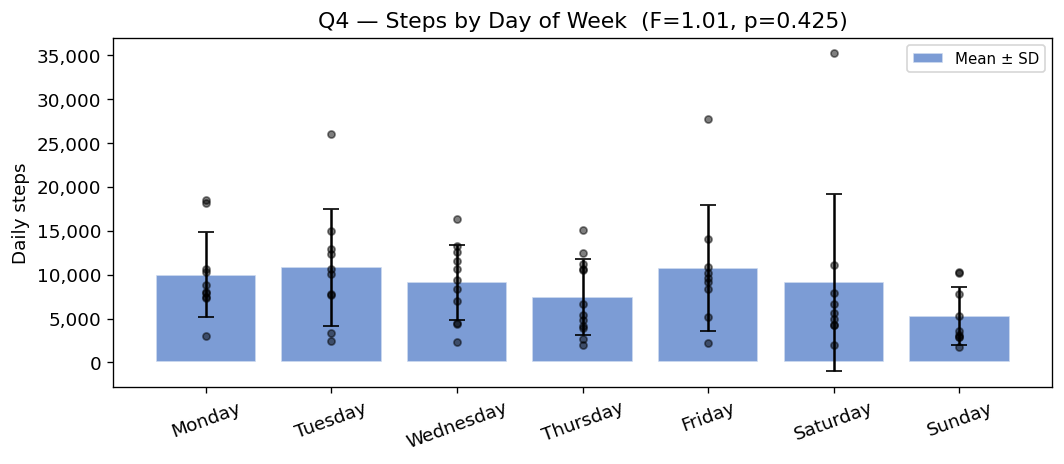

In [9]:
# Combine all 4 participants into one DataFrame and label each row with its day of week
ag_all_df = pd.concat(ag.values()).sort_index().reset_index()
ag_all_df.columns = ["date","Steps"]
ag_all_df["dow"]  = ag_all_df["date"].dt.day_name()

# Define the order of days so Monday comes first in the chart
days   = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# Build one list of step values for each day of the week
# Drop any day that has fewer than 2 observations — we cannot compute std without 2
groups = [ag_all_df.loc[ag_all_df["dow"]==d,"Steps"].tolist() for d in days]
groups = [g for g in groups if len(g) >= 2]

print(f"Days: {len(groups)}  |  Obs per day: {[len(g) for g in groups]}")

# Run the one-way ANOVA with 7 groups (one per day of the week)
# The question: does the day of the week predict how many steps someone takes?
F_dow, df_b, df_w, p_dow = anova_one_way(*groups)
print(f"F={F_dow:.4f}  df_between={df_b}  df_within={df_w}  p={p_dow:.4f}")
print("→ Reject H₀: day-of-week effect (p<0.05)." if p_dow < 0.05
      else "→ Fail to reject H₀: no significant day-of-week effect (p≥0.05).")

# Bar chart showing mean steps per day with standard deviation error bars
means_d = [arithmetic_mean(g) for g in groups]
sds_d   = [sample_std(g)      for g in groups]

fig, ax = plt.subplots(figsize=(9, 4))

# Bars show the group means — error bars show one SD above and below
ax.bar(days, means_d, yerr=sds_d, capsize=5,
       color="#4472C4", alpha=0.7, edgecolor="white", label="Mean ± SD")

# Overlay individual data points so the reader can judge the spread themselves
# Small black dots for each individual day of observation
for i, (day, g) in enumerate(zip(days, groups)):
    ax.scatter([i]*len(g), g, color="black", s=18, alpha=0.5, zorder=3)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))
ax.set_ylabel("Daily steps")
ax.legend(fontsize=9)
ax.set_title(f"Q4 — Steps by Day of Week  (F={F_dow:.2f}, p={p_dow:.3f})")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


**Answer — Q4**

F = 1.0139, df_between = 6, df_within = 63, **p = 0.4245**.

**Fail to reject H₀**: no statistically significant day-of-week difference in step counts
at α = 0.05. These participants do not show a "weekend warrior" pattern.

With 4 participants over ~2 weeks, each day-of-week cell has 9–12 observations.
This gives low-to-moderate power to detect moderate effects (Cohen's f ≈ 0.25).
A longer monitoring period or more participants would substantially increase power.


---
### Q5 — Seasonality (repeated-measures ANOVA)
> *Across the two years, were all months travelled equally?*

Subjects (years): [2013, 2014]
Conditions (months): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

month      1       2       3       4       5       6       7       8       9       10
year                                                                                 
2013   5990.9  6784.7  5265.4  3671.2  4195.1  7284.8  4507.6  5981.7  4063.8  2323.1
2014   3343.8     2.4  4213.6  2788.3   433.0  3287.7    97.7   954.4  5070.4  5380.5
F=0.4736  df_conditions=9  df_error=9  p=0.8596
→ Fail to reject H₀: no significant monthly variation (p≥0.05).


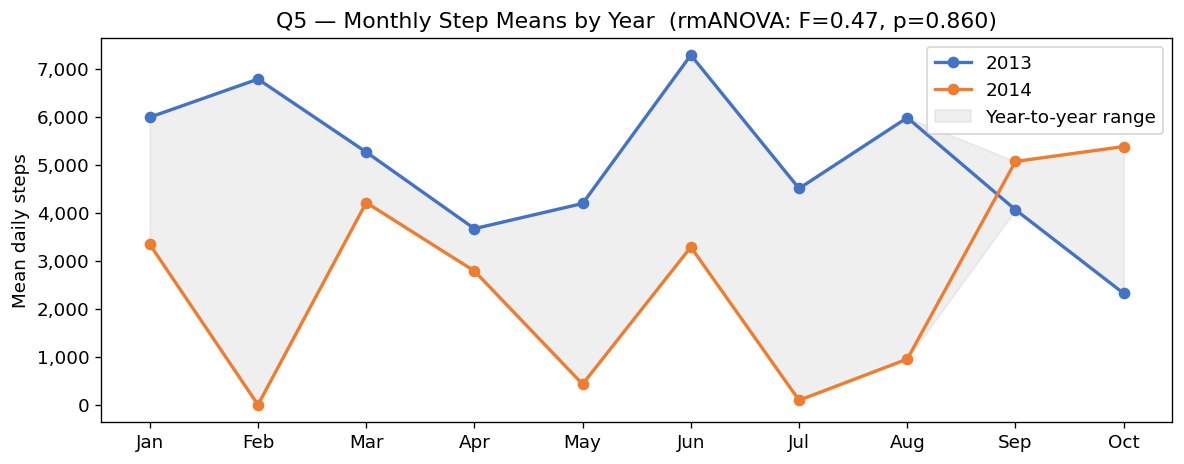

In [10]:
# Prepare the multiyear data by extracting year and month from each date
multi_df          = multi.reset_index()
multi_df.columns  = ["date","Steps"]
multi_df["year"]  = multi_df["date"].dt.year
multi_df["month"] = multi_df["date"].dt.month

# Use only 2013 and 2014 as subjects (rows in the rmANOVA matrix)
# WHY exclude 2012?
# 2012 only has data for December — it cannot serve as a complete subject
# because it is missing 11 of the 12 months needed to match the other years
sub     = multi_df[multi_df["year"].isin([2013, 2014])]

# Compute the mean daily steps for each (year, month) combination
# Then pivot so rows = years (subjects) and columns = months (conditions)
# dropna(axis=1) keeps only months that have data in BOTH years
monthly = sub.groupby(["year","month"])["Steps"].mean().unstack().dropna(axis=1)

print(f"Subjects (years): {monthly.index.tolist()}")
print(f"Conditions (months): {monthly.columns.tolist()}")
print()
print(monthly.round(1).to_string())

# Convert the pivot table to a plain list-of-lists for the rmanova function
mat = monthly.values.tolist()

# Run the repeated-measures ANOVA
# Design: 2 subjects (years) x 10 conditions (months Jan-Oct)
F_rm, df_c, df_e, p_rm = rmanova(mat)
print(f"F={F_rm:.4f}  df_conditions={df_c}  df_error={df_e}  p={p_rm:.4f}")
print("→ Reject H₀: monthly steps differ (p<0.05)." if p_rm < 0.05
      else "→ Fail to reject H₀: no significant monthly variation (p≥0.05).")

# Line plot showing mean daily steps per month, one line per year
# The shaded area shows the range between the two years for each month
month_labels = [calendar.month_abbr[m] for m in monthly.columns]

fig, ax = plt.subplots(figsize=(10, 4))

colors = ["#4472C4","#ED7D31"]
rows   = [monthly.loc[yr].tolist() for yr in monthly.index]

# Plot one line per year
for yr, row, color in zip(monthly.index, rows, colors):
    ax.plot(month_labels, row, marker="o", label=str(yr), color=color, lw=2)

# Shade the gap between years so the reader can see month-by-month agreement
ax.fill_between(
    month_labels,
    [min(r[i] for r in rows) for i in range(len(month_labels))],
    [max(r[i] for r in rows) for i in range(len(month_labels))],
    alpha=0.12, color="gray", label="Year-to-year range"
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:,.0f}"))
ax.set_ylabel("Mean daily steps")
ax.legend()
ax.set_title(f"Q5 — Monthly Step Means by Year  (rmANOVA: F={F_rm:.2f}, p={p_rm:.3f})")
plt.tight_layout(); plt.show()


**Answer — Q5**

**Design:** years (2013, 2014) serve as **subjects** (n = 2);  
months January–October (present in both years) serve as **conditions** (k = 10).  
2012 is excluded because only December is available — it cannot serve as a complete subject.  
Each cell = mean daily steps for that year × month combination.

F = 0.4736, df_conditions = 9, df_error = 9, **p = 0.8596**.

**Fail to reject H₀**: no statistically significant monthly variation detected.

**Why this result must be interpreted with caution:**

1. *Statistical power:* df_error = (k−1)(n−1) = 9 × 1 = 9. With n = 2 subjects,
   the test is severely underpowered. Even a large seasonal effect would likely
   not reach significance.

2. *Data quality:* 2014 shows near-zero step counts in February (mean = 2.4 steps/day)
   and July (mean = 97.7 steps/day). These almost certainly reflect extended non-wear
   periods rather than true behaviour, which violates the assumption that
   missing data are random.

3. *Conclusion:* The non-significant result **should not be interpreted as evidence
   that no seasonality exists**. To draw meaningful conclusions, a minimum of
   5–10 years of complete data would be needed.


---
## 5. Summary

| Q | Method | Key result | Interpretation |
|---|---|---|---|
| Q1 Daily steps | Arithmetic & harmonic mean (all 4 Ps, n=70) | AM = 8,944 / HM = 5,826 | Harmonic always lower; right-skewed distribution |
| Q2 Group variance | Pooled SD (k=4, self-identified) | σ_p = 5,334 steps/day | High day-to-day variability; P3 drives estimate |
| Q3 Device comparison | Two-sample t-test (arithmetic + harmonic flag) | t = -1.78, df = 134, p = 0.077 | No significant difference pooled; Fitbit tends to overcount |
| Q4 Weekend warriors | One-way ANOVA (7 day-of-week groups) | F = 1.01, p = 0.425 | No significant day-of-week effect |
| Q5 Seasonality | Repeated-measures ANOVA | F = 0.47, p = 0.860 | No significant monthly effect; severely underpowered (n=2 years) |

---
